# Exploratory Data Analysis

Reads the cleaned dataset produced by `02_data_cleaning.ipynb` (`data/processed/demand_clean.csv`).

In [ ]:
import os
import sys
from pathlib import Path

import yaml

# Works both in the local repo and on Kaggle. Locally, config.yaml is read
# from disk. On Kaggle there is no repo checkout -- only whatever cells you
# paste -- so the config is built inline instead. This notebook only reads
# from /kaggle/working (produced by 02_data_cleaning.ipynb earlier in the
# same Kaggle session), never from /kaggle/input, so IS_KAGGLE just needs
# KAGGLE_KERNEL_RUN_TYPE (always set on Kaggle) -- no dataset needs to be
# attached for this notebook specifically.
IS_KAGGLE = "KAGGLE_KERNEL_RUN_TYPE" in os.environ

if IS_KAGGLE:
    REPO_ROOT = Path("/kaggle/working")
    config = {
        "data": {
            "processed_file": "/kaggle/working/data/processed/demand_clean.csv",
            "timestamp_col": "timestamp",
            "target_col": "demand",
            "frequency": "h",
        },
        "peak_demand": {"percentile_threshold": 0.95, "seasonal": True},
    }
else:
    def find_repo_root(start: Path) -> Path:
        for parent in [start, *start.parents]:
            if (parent / "config.yaml").exists():
                return parent
        raise FileNotFoundError("config.yaml not found in any parent directory")

    REPO_ROOT = find_repo_root(Path.cwd())
    sys.path.insert(0, str(REPO_ROOT))

    with open(REPO_ROOT / "config.yaml") as f:
        config = yaml.safe_load(f)

config

In [2]:
import matplotlib.pyplot as plt
import pandas as pd
import seaborn as sns

# Same Kaggle-vs-local split as notebook 02 -- see that notebook's note.
if IS_KAGGLE:
    def load_raw_data(path, timestamp_col="timestamp"):
        df = pd.read_csv(path, parse_dates=[timestamp_col])
        return df.sort_values(timestamp_col).reset_index(drop=True)

    def set_timestamp_index(df, timestamp_col="timestamp"):
        df = df.set_index(timestamp_col)
        return df.sort_index()
else:
    from src.data.load_data import load_raw_data, set_timestamp_index

PROCESSED_PATH = REPO_ROOT / config["data"]["processed_file"]
TIMESTAMP_COL = config["data"]["timestamp_col"]
TARGET_COL = config["data"]["target_col"]

sns.set_theme(style="whitegrid")

## Load the cleaned dataset

In [3]:
df = load_raw_data(PROCESSED_PATH, TIMESTAMP_COL)
df = set_timestamp_index(df, TIMESTAMP_COL)
df["hour"] = df.index.hour
df["day_of_week"] = df.index.dayofweek
df["month"] = df.index.month
df["is_weekend"] = df["day_of_week"].isin([5, 6])
df.head()

,demand,temperature,humidity,wind_speed,rainfall,solar_irradiance,gdp,per_capita_energy_use,electricity_price,public_event,hour,day_of_week,month,is_weekend
timestamp,,,,,,,,,,,,,,
2020-01-01 00:00:00,1626.458412,29.264584,78.596059,2.010490,4.722857,283.256083,978.313852,489.264274,23.840111,1,0,2,1,False
2020-01-01 01:00:00,1593.917861,28.939179,78.981324,2.017491,3.804590,229.819735,935.434256,505.759101,24.308850,0,1,2,1,False
2020-01-01 02:00:00,1457.196911,27.571969,77.364594,1.972281,5.686889,263.726759,965.089335,491.523802,30.762810,0,2,2,1,False
2020-01-01 03:00:00,1302.073833,26.020738,79.678678,1.615092,5.024458,250.467925,988.898933,495.765616,26.104404,1,3,2,1,False
2020-01-01 04:00:00,1349.054422,26.490544,80.105671,2.280944,2.721659,255.340872,1032.194114,497.929332,22.300232,0,4,2,1,False


## Overall demand trend

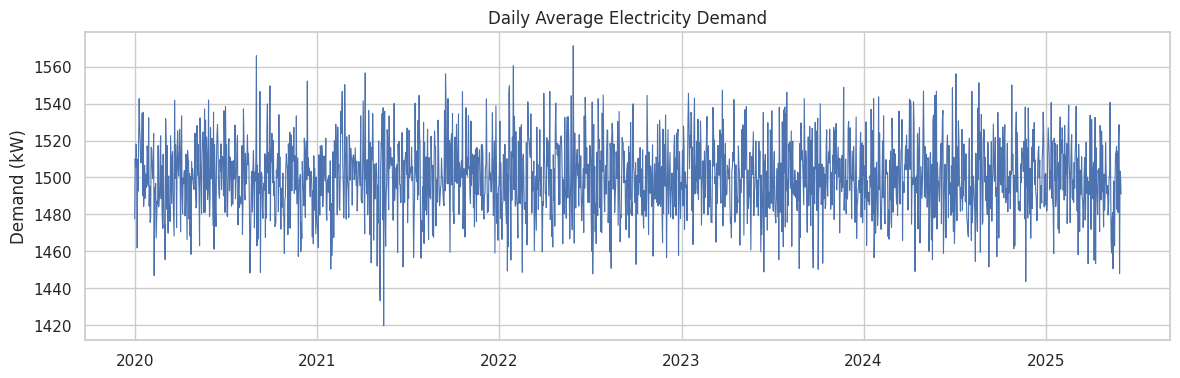

In [4]:
daily_demand = df[TARGET_COL].resample("D").mean()

fig, ax = plt.subplots(figsize=(14, 4))
ax.plot(daily_demand.index, daily_demand.values, linewidth=0.8)
ax.set_title("Daily Average Electricity Demand")
ax.set_ylabel("Demand (kW)")
plt.show()

## Hourly demand pattern

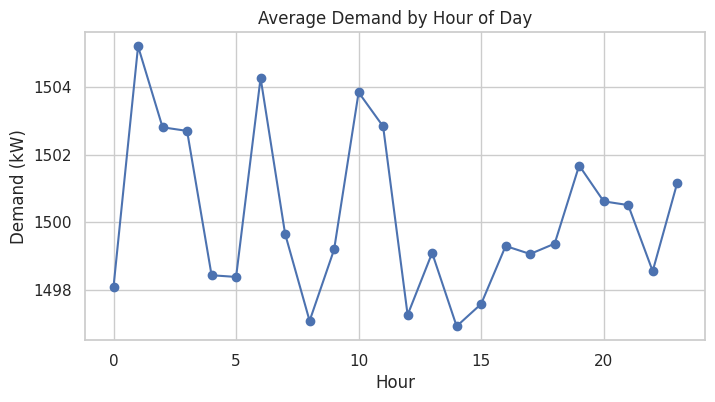

In [5]:
hourly_avg = df.groupby("hour")[TARGET_COL].mean()

fig, ax = plt.subplots(figsize=(8, 4))
ax.plot(hourly_avg.index, hourly_avg.values, marker="o")
ax.set_title("Average Demand by Hour of Day")
ax.set_xlabel("Hour")
ax.set_ylabel("Demand (kW)")
plt.show()

## Weekly (day-of-week) demand pattern

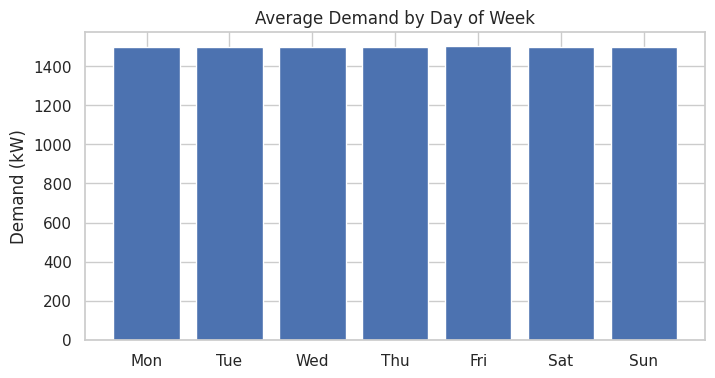

In [6]:
dow_labels = ["Mon", "Tue", "Wed", "Thu", "Fri", "Sat", "Sun"]
dow_avg = df.groupby("day_of_week")[TARGET_COL].mean()

fig, ax = plt.subplots(figsize=(8, 4))
ax.bar(dow_labels, dow_avg.values)
ax.set_title("Average Demand by Day of Week")
ax.set_ylabel("Demand (kW)")
plt.show()

## Monthly / seasonal demand pattern

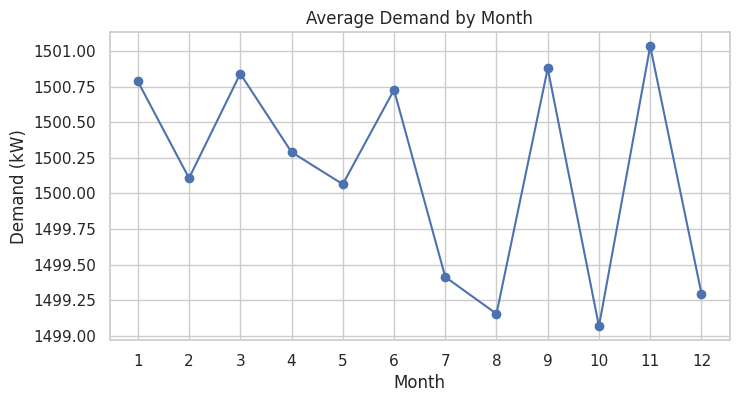

In [7]:
month_avg = df.groupby("month")[TARGET_COL].mean()

fig, ax = plt.subplots(figsize=(8, 4))
ax.plot(month_avg.index, month_avg.values, marker="o")
ax.set_title("Average Demand by Month")
ax.set_xlabel("Month")
ax.set_ylabel("Demand (kW)")
ax.set_xticks(range(1, 13))
plt.show()

## Weekday vs weekend comparison

/tmp/ipykernel_155/1190207467.py:3: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  ax.set_xticklabels(["Weekday", "Weekend"])


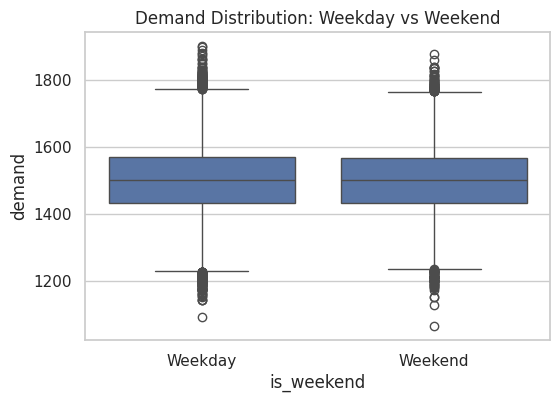

In [8]:
fig, ax = plt.subplots(figsize=(6, 4))
sns.boxplot(data=df, x="is_weekend", y=TARGET_COL, ax=ax)
ax.set_xticklabels(["Weekday", "Weekend"])
ax.set_title("Demand Distribution: Weekday vs Weekend")
plt.show()

## Demand distribution

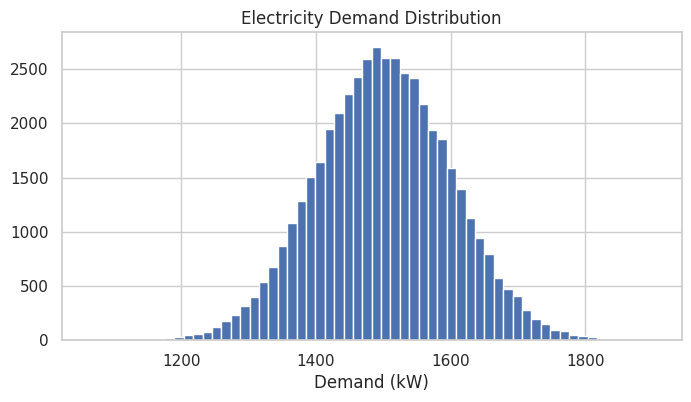

In [9]:
fig, ax = plt.subplots(figsize=(8, 4))
ax.hist(df[TARGET_COL].dropna(), bins=60)
ax.set_title("Electricity Demand Distribution")
ax.set_xlabel("Demand (kW)")
plt.show()

## Peak-demand hours

Uses the same 95th-percentile threshold defined in `config.yaml` (`peak_demand.percentile_threshold`) and proposal.txt Section 21.

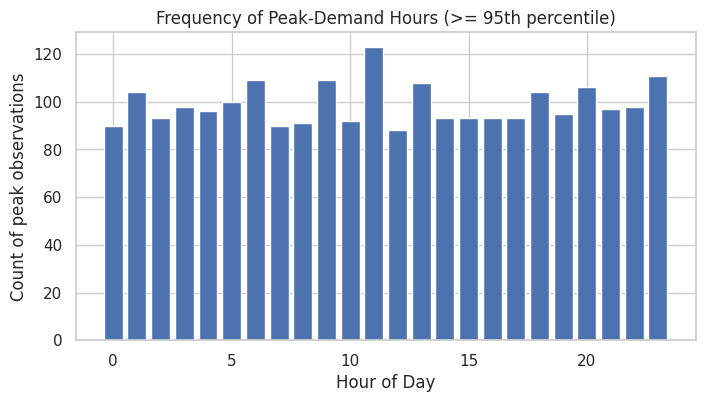

In [10]:
peak_threshold = df[TARGET_COL].quantile(config["peak_demand"]["percentile_threshold"])
peak_hours = df[df[TARGET_COL] >= peak_threshold]["hour"].value_counts().sort_index()

fig, ax = plt.subplots(figsize=(8, 4))
ax.bar(peak_hours.index, peak_hours.values)
ax.set_title("Frequency of Peak-Demand Hours (>= 95th percentile)")
ax.set_xlabel("Hour of Day")
ax.set_ylabel("Count of peak observations")
plt.show()

## Weather-demand relationships

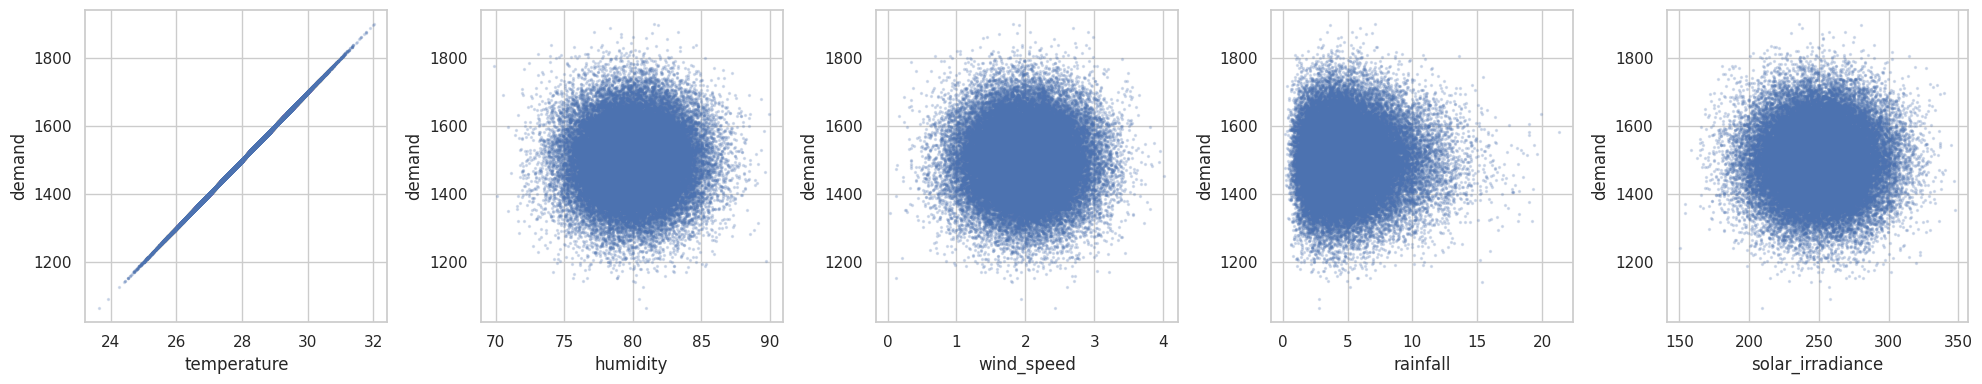

In [11]:
weather_cols = [c for c in ["temperature", "humidity", "wind_speed", "rainfall", "solar_irradiance"] if c in df.columns]

fig, axes = plt.subplots(1, len(weather_cols), figsize=(4 * len(weather_cols), 4))
for ax, col in zip(axes, weather_cols):
    ax.scatter(df[col], df[TARGET_COL], s=2, alpha=0.2)
    ax.set_xlabel(col)
    ax.set_ylabel(TARGET_COL)
plt.tight_layout()
plt.show()

## Correlation analysis

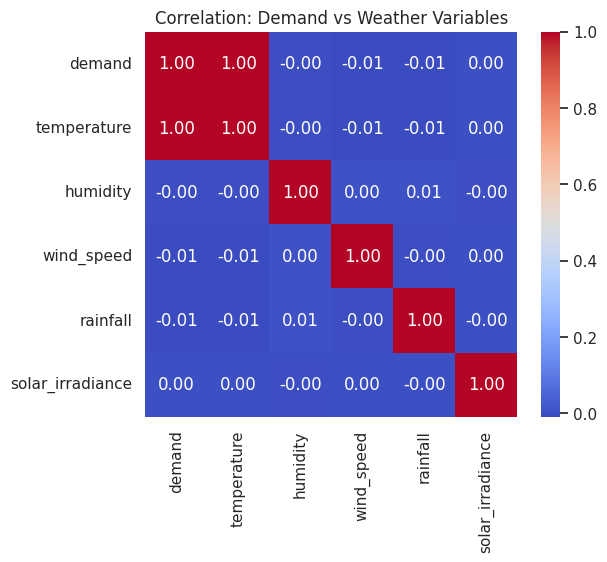

In [12]:
corr_cols = [TARGET_COL] + weather_cols
corr = df[corr_cols].corr()

fig, ax = plt.subplots(figsize=(6, 5))
sns.heatmap(corr, annot=True, fmt=".2f", cmap="coolwarm", ax=ax)
ax.set_title("Correlation: Demand vs Weather Variables")
plt.show()